# 03 — EDA: OTRF Dataset

The Open Threat Research Federation (OTRF) dataset is a collection of **red-team simulations** captured as Windows Sysmon events. Unlike LMD-2023 (CSV rows) and SILRAD (pre-embedded float vectors), OTRF data arrives as **NDJSON** (newline-delimited JSON) inside ZIP archives — one flat event object per line.

Two sub-collections are available:

| Sub-dataset | Description | Events |
|-------------|-------------|--------|
| **APT29 (compound)** | Full multi-stage APT simulation — MITRE ATT&CK evaluation, Day 1 & Day 2 | ~551 k |
| **Atomic** | Individual T-code exercises (130+ techniques, isolated executions) | ~564 k |

**Goals of this notebook:**
- Understand which ATT&CK tactics and techniques are covered by our Knowledge Base (KB)
- Characterise the APT29 campaign through EventID distributions, process trees, DNS, and network activity
- Validate that atomic technique events ingest correctly through the canonical schema
- Identify data quality issues before training

In [1]:
import sys
sys.path.insert(0, r'h:\Challenge-3-4\cyber-anomaly-detection')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path

sns.set_theme(style='whitegrid')
%matplotlib inline

## ATT&CK Knowledge Base (KB)

Before touching raw events we load the **ATT&CK Knowledge Base** — a lookup table mapping MITRE ATT&CK technique IDs (T-codes) to their associated tactics, descriptions, and Sysmon data sources.

The KB is built from two YAML corpora:

| Source | Role |
|--------|------|
| **OTRF detection rules** | Community Sigma-style rules aligned to OTRF simulations |
| **Splunk Security Content** | Splunk's open-source detection library, extending T-code coverage |

Each KB entry answers: *"What ATT&CK technique does this rule detect, and under which tactic?"* At training time the KB drives ground-truth `attck_technique` label assignment for raw Sysmon events.

## APT29 Event Loading

In [2]:
# Load ATT&CK KB metadata (OTRF + Splunk YAML)
from data.attack_kb.builder import build_kb

kb = build_kb()
print(f'KB entries: {len(kb)}')

# Technique coverage
tids = [e.technique_id for e in kb if e.technique_id]
tactics = [t for e in kb for t in e.tactic_ids]
print(f'Unique technique IDs: {len(set(tids))}')
print(f'Unique tactics      : {sorted(set(tactics))}')

KB entries: 256
Unique technique IDs: 256
Unique tactics      : ['TA0001', 'TA0002', 'TA0003', 'TA0004', 'TA0005', 'TA0006', 'TA0007', 'TA0008', 'TA0009']


F:\GECAD\_cache\tmp\ipykernel_29912\2546031904.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tac_df, x='count', y='tactic', ax=ax, palette='mako_r')


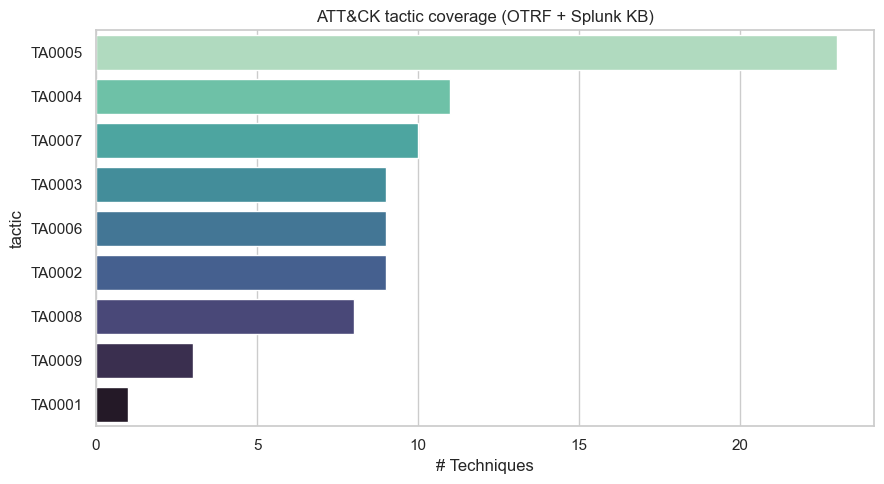

In [3]:
# Tactic distribution
tactic_counts = Counter(tactics)
tac_df = pd.DataFrame(tactic_counts.most_common(), columns=['tactic', 'count'])

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=tac_df, x='count', y='tactic', ax=ax, palette='mako_r')
ax.set_title('ATT&CK tactic coverage (OTRF + Splunk KB)')
ax.set_xlabel('# Techniques')
plt.tight_layout()
plt.show()

In [4]:
# Load all APT29 events
from data.ingest.otrf import iter_apt29

apt29_chunks = []
rows_seen = 0

for chunk in iter_apt29():
    apt29_chunks.append(chunk)
    rows_seen += len(chunk)

if apt29_chunks:
    df_apt29 = pd.concat(apt29_chunks, ignore_index=True)
    print(f'APT29 events loaded: {len(df_apt29):,}')
    print(df_apt29.dtypes)
else:
    print('No APT29 data found — check OTRF ZIP paths.')
    df_apt29 = pd.DataFrame()

APT29 events loaded: 551,149
event_id            int16
utc_time           object
process_guid       object
process_id          int32
image              object
command_line       object
current_dir        object
user               object
integrity_level    object
parent_guid        object
parent_id           int32
parent_image       object
parent_cmdline     object
image_loaded       object
signed             object
signature          object
sig_status         object
target_object      object
details            object
target_image       object
granted_access     object
call_trace         object
dest_ip            object
dest_port           int32
dest_hostname      object
target_filename    object
event_type         object
pipe_name          object
query_name         object
query_results      object
rule_name          object
hashes             object
label                int8
dataset_source     object
attck_technique    object
dtype: object


## EventID Distribution

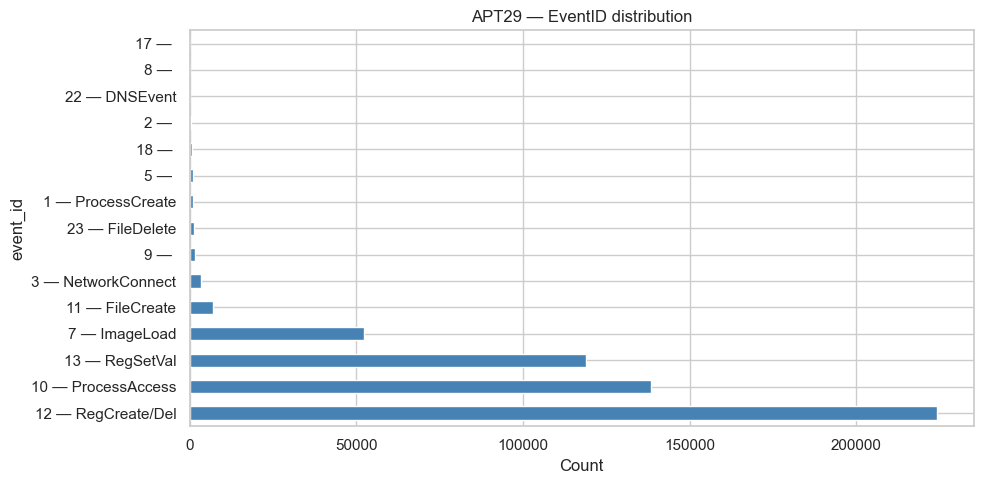

In [5]:
if not df_apt29.empty:
    # EventID distribution
    eid_map = {
        1: 'ProcessCreate', 3: 'NetworkConnect', 7: 'ImageLoad',
        10: 'ProcessAccess', 11: 'FileCreate', 12: 'RegCreate/Del',
        13: 'RegSetVal', 22: 'DNSEvent', 23: 'FileDelete',
    }
    eid_series = pd.to_numeric(df_apt29['event_id'], errors='coerce').dropna().astype(int)
    eid_counts = eid_series.value_counts().head(15)
    eid_counts.index = eid_counts.index.map(lambda x: f'{x} — {eid_map.get(x, "")}')

    fig, ax = plt.subplots(figsize=(10, 5))
    eid_counts.plot.barh(ax=ax, color='steelblue')
    ax.set_title('APT29 — EventID distribution')
    ax.set_xlabel('Count')
    plt.tight_layout()
    plt.show()

## Top Process Images

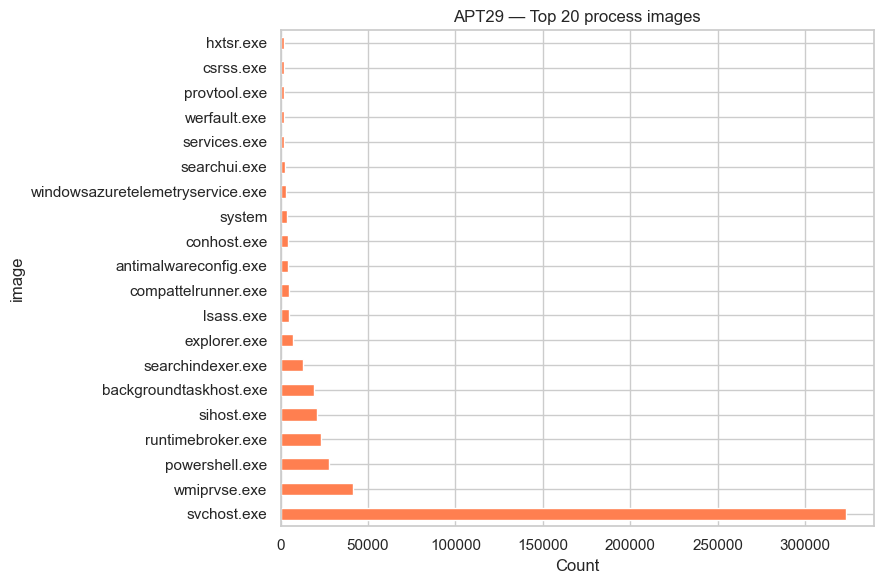

In [6]:
if not df_apt29.empty and 'image' in df_apt29.columns:
    # Top 20 process images
    img_counts = (
        df_apt29['image'].dropna()
             .str.split('\\').str[-1]
             .str.lower()
             .value_counts()
             .head(20)
    )
    fig, ax = plt.subplots(figsize=(9, 6))
    img_counts.plot.barh(ax=ax, color='coral')
    ax.set_title('APT29 — Top 20 process images')
    ax.set_xlabel('Count')
    plt.tight_layout()
    plt.show()

## KB T-code Frequency

F:\GECAD\_cache\tmp\ipykernel_29912\1627410827.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_tids, x='count', y='technique_id', ax=ax, palette='viridis')


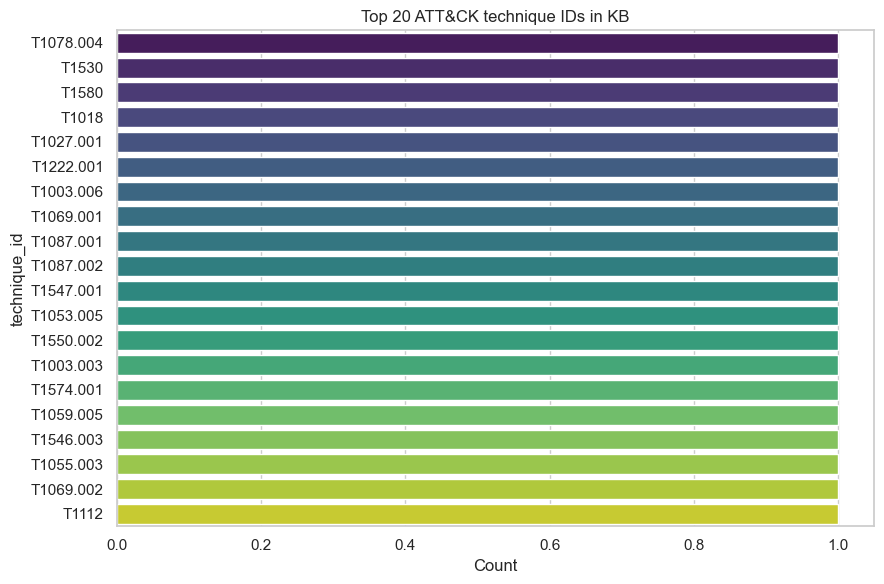

In [7]:
# Technique T-code frequency in KB
from collections import Counter as TechCounter

tid_counts = TechCounter(tids)
top_tids = pd.DataFrame(tid_counts.most_common(20), columns=['technique_id', 'count'])

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=top_tids, x='count', y='technique_id', ax=ax, palette='viridis')
ax.set_title('Top 20 ATT&CK technique IDs in KB')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

## KB → Atomic Event Validation

This section serves two purposes:

1. **T-code scan** — extract MITRE technique IDs embedded in atomic ZIP filenames (e.g. `T1059.001_powershell_exec.zip`) to measure how much of the KB the atomic corpus covers.
2. **Schema validation** — load all atomic events through `iter_atomic()` to confirm they flow correctly through the canonical schema before being used in training.

> **Known limitation:** OTRF atomic ZIPs use descriptive filenames (e.g. `ec2_proxy_s3_exfiltration.zip`) rather than T-code prefixes, so the regex filename scan will find 0 matches. T-code metadata for atomic exercises lives in the `_metadata/` YAML directory (`OTRF_ATOMIC_META`) and requires a separate parser. The ingestion of raw events via `iter_atomic()` still works correctly.

In [17]:
import importlib
import data.ingest.otrf as _otrf_mod
importlib.reload(_otrf_mod)
from data.ingest.otrf import iter_atomic, _build_atomic_tcode_map

# Show the T-code map built from YAML metadata
tcode_map = _build_atomic_tcode_map()
print(f'ZIPs with T-code from metadata : {len(tcode_map)}')
print(f'Unique T-codes                 : {len(set(tcode_map.values()))}')

# Load full windows atomic dataset
at_chunks = []
for chunk in iter_atomic():
    at_chunks.append(chunk)

df_at = pd.concat(at_chunks, ignore_index=True)
print(f'\nAtomic events loaded           : {len(df_at):,}')
print(f'Label distribution             : {df_at["label"].value_counts().to_dict()}')
print(f'\nTop T-codes by event count:')
print(df_at[df_at['attck_technique'] != '']['attck_technique'].value_counts().head(15).to_string())
print(f'\nevent_id distribution (top 10):')
print(df_at['event_id'].value_counts().head(10).to_string())

ZIPs with T-code from metadata : 110
Unique T-codes                 : 53

Atomic events loaded           : 564,084
Label distribution             : {1: 543077, -1: 21007}

Top T-codes by event count:
attck_technique
T1562.002    174922
T1021.003     76186
T1546.003     64574
T1053.005     39780
T1047         27003
T1003.003     22866
T1110.003     22054
T1547.001     20285
T1021.002     13739
T1003.002      6848
T1003.001      6578
T1123          5397
T1055.001      5320
T1003.004      5247
T1021.006      5002

event_id distribution (top 10):
event_id
10    251174
12    148816
7      76627
13     65198
11      6659
3       3843
9       2861
23      2023
1       1540
18      1520


## APT29 Day 1 vs Day 2 Comparison

The APT29 simulation is split across two days representing distinct campaign phases:

| Day | Phase | Key ATT&CK stages |
|-----|-------|-------------------|
| **Day 1** | Initial compromise | Spearphishing (TA0001), Execution (TA0002), Persistence (TA0003) |
| **Day 2** | Post-compromise | Lateral Movement (TA0008), Credential Access (TA0006), Collection (TA0009) |

Comparing the two days lets us understand how **event volume, event type mix, and activity rate** differ between the noisy initial-compromise phase and the more sustained lateral-movement phase — a useful prior for tuning the anomaly detector's sensitivity over time.

day1: 143,884 events
day2: 407,265 events


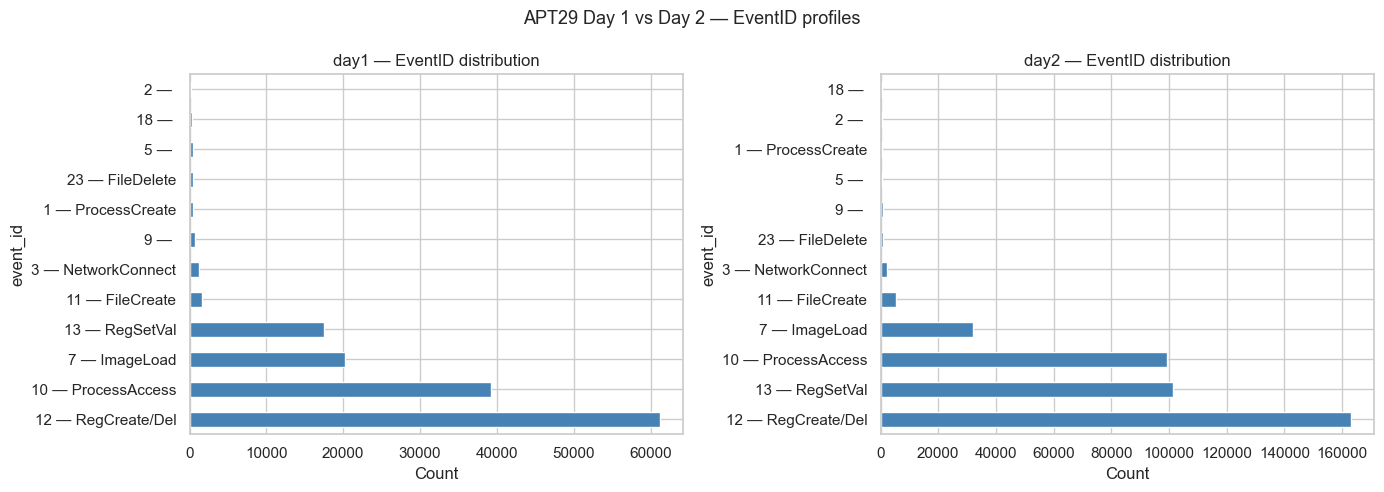

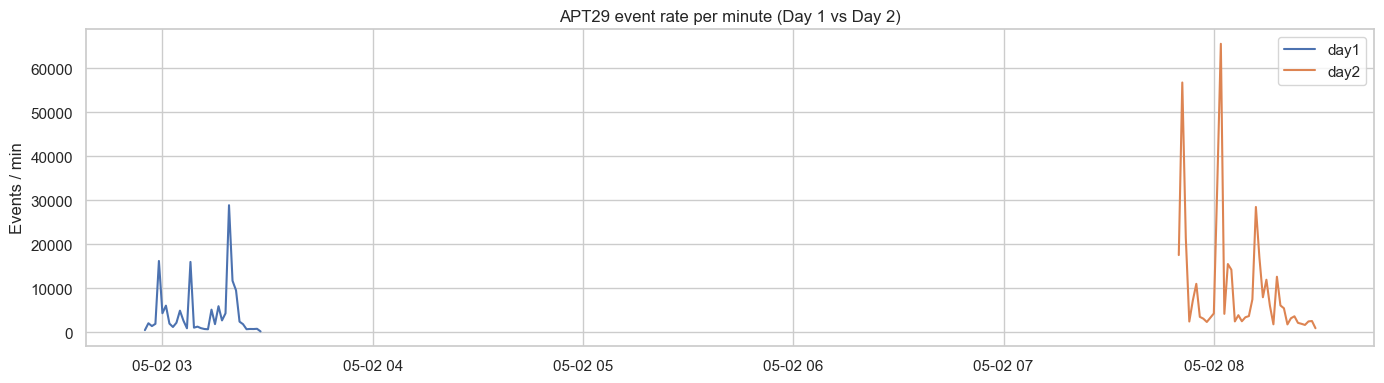

In [16]:
from data.ingest.otrf import _parse_zip
from config import OTRF_APT29_DIR

day_frames = {}
for day_dir in sorted(OTRF_APT29_DIR.glob('day*')):
    chunks, rows = [], 0
    for zp in sorted(day_dir.rglob('*.zip')):
        for chunk in _parse_zip(zp, chunksize=5_000, source_tag=day_dir.name):
            chunks.append(chunk)
            rows += len(chunk)
    if chunks:
        day_frames[day_dir.name] = pd.concat(chunks, ignore_index=True)
        print(f'{day_dir.name}: {len(day_frames[day_dir.name]):,} events')

if len(day_frames) >= 2:
    fig, axes = plt.subplots(1, len(day_frames), figsize=(7 * len(day_frames), 5))
    for ax, (day, df_day) in zip(axes, day_frames.items()):
        ec = (pd.to_numeric(df_day['event_id'], errors='coerce')
              .dropna().astype(int).value_counts().head(12))
        ec.index = ec.index.map(lambda x: f'{x} — {eid_map.get(x, "")}')
        ec.plot.barh(ax=ax, color='steelblue')
        ax.set_title(f'{day} — EventID distribution')
        ax.set_xlabel('Count')
    plt.suptitle('APT29 Day 1 vs Day 2 — EventID profiles', fontsize=13)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(14, 4))
    for day, df_day in day_frames.items():
        ts = pd.to_datetime(df_day['utc_time'], errors='coerce').dropna()
        if not ts.empty:
            rate = ts.dt.floor('1min').value_counts().sort_index()
            ax.plot(rate.index, rate.values, label=day)
    ax.set_title('APT29 event rate per minute (Day 1 vs Day 2)')
    ax.set_ylabel('Events / min')
    ax.legend()
    plt.tight_layout()
    plt.show()
elif day_frames:
    print(f'Only one day directory found: {list(day_frames.keys())}')
else:
    print('No APT29 day directories found — check OTRF_APT29_DIR path.')

## DNS & Network Activity (EventIDs 3 & 22)

Network events are the strongest signal for **C2 communication** and **lateral movement** detection:

- **EventID 22 (DNSEvent)** — fired every time a process resolves a hostname. C2 frameworks beacon periodically to their command server; unusual or high-frequency queries to unknown domains are a red flag (T1071.004 — Application Layer Protocol: DNS).
- **EventID 3 (NetworkConnect)** — fired on every outbound TCP/UDP connection attempt. Reveals destination IP, port, and the initiating process. Connections from `powershell.exe` or `rundll32.exe` to port 443/80 are classic C2 indicators (T1071.001).

DNS events  (EID 22): 226
Net events  (EID 3) : 3,415


F:\GECAD\_cache\tmp\ipykernel_29912\2004797834.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_q, x='count', y='query_name', ax=axes[0], palette='Blues_r')
F:\GECAD\_cache\tmp\ipykernel_29912\2004797834.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_ip, x='count', y='dest_ip', ax=axes[1], palette='Oranges_r')
F:\GECAD\_cache\tmp\ipykernel_29912\2004797834.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_port, x='count', y='dest_port', ax=axes[2], palette='Greens_r')


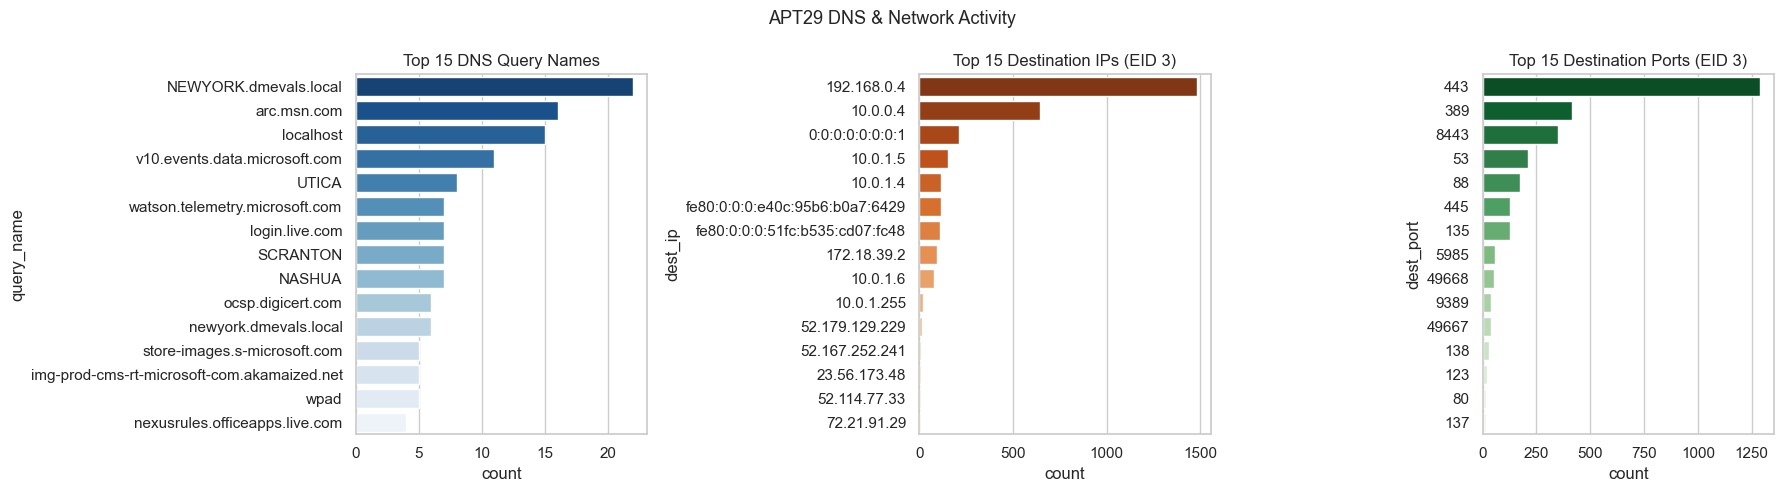

In [10]:
if not df_apt29.empty:
    df_dns  = df_apt29[df_apt29['event_id'] == 22].copy()
    df_net3 = df_apt29[df_apt29['event_id'] == 3].copy()

    print(f'DNS events  (EID 22): {len(df_dns):,}')
    print(f'Net events  (EID 3) : {len(df_net3):,}')

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Top DNS query names
    if not df_dns.empty:
        top_q = (df_dns['query_name'].replace('', pd.NA).dropna()
                 .value_counts().head(15).reset_index())
        top_q.columns = ['query_name', 'count']
        sns.barplot(data=top_q, x='count', y='query_name', ax=axes[0], palette='Blues_r')
        axes[0].set_title('Top 15 DNS Query Names')
    else:
        axes[0].text(0.5, 0.5, 'No DNS events in sample', ha='center', va='center')
        axes[0].set_title('DNS Query Names')

    # Top destination IPs
    if not df_net3.empty:
        top_ip = df_net3['dest_ip'].value_counts().head(15).reset_index()
        top_ip.columns = ['dest_ip', 'count']
        sns.barplot(data=top_ip, x='count', y='dest_ip', ax=axes[1], palette='Oranges_r')
        axes[1].set_title('Top 15 Destination IPs (EID 3)')

        top_port = (pd.to_numeric(df_net3['dest_port'], errors='coerce')
                    .dropna().astype(int).value_counts().head(15).reset_index())
        top_port.columns = ['dest_port', 'count']
        top_port['dest_port'] = top_port['dest_port'].astype(str)
        sns.barplot(data=top_port, x='count', y='dest_port', ax=axes[2], palette='Greens_r')
        axes[2].set_title('Top 15 Destination Ports (EID 3)')
    else:
        axes[1].text(0.5, 0.5, 'No network events in sample', ha='center', va='center')
        axes[2].text(0.5, 0.5, 'No network events in sample', ha='center', va='center')

    plt.suptitle('APT29 DNS & Network Activity', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('df_apt29 is empty — run the APT29 ingestion cell first.')

## Process Parent-Child Relationship Patterns

In Windows every process has a parent. **Unexpected spawn chains** are one of the most reliable anomaly signals because:

- Legitimate software follows predictable patterns (e.g. `services.exe → svchost.exe`, `explorer.exe → notepad.exe`)
- Attackers abuse trusted binaries as launchers to avoid allowlist controls (**LOLBin abuse**)
- Macro-based delivery creates telltale chains like `winword.exe → cmd.exe → powershell.exe`

This section counts the most frequent parent → child pairs across the full APT29 campaign and flags spawns from a set of known-suspicious parent processes.

F:\GECAD\_cache\tmp\ipykernel_29912\622286297.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_pairs, x='count', y='parent → child', ax=ax, palette='rocket_r')


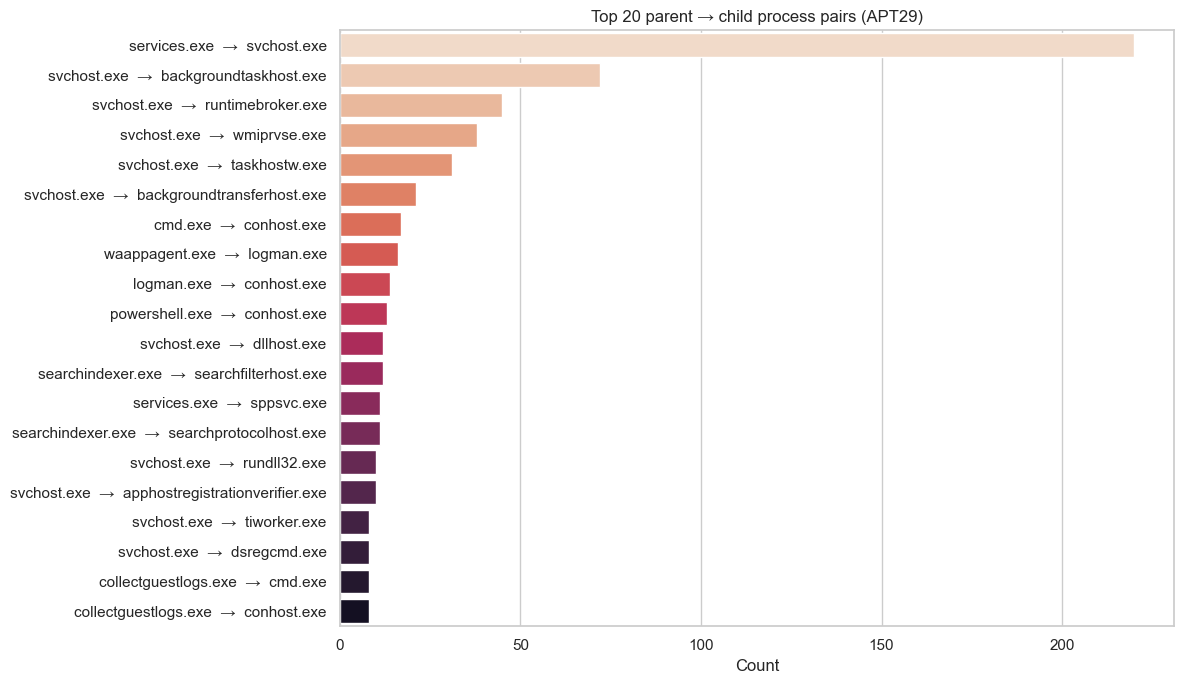

Suspicious spawn pairs:
pair
explorer.exe  →  securityhealthsystray.exe    2
explorer.exe  →  â€®cod.3aka3.scr             1
explorer.exe  →  notepad.exe                  1
explorer.exe  →  cmd.exe                      1
explorer.exe  →  powershell.exe               1
explorer.exe  →  update.exe                   1
explorer.exe  →  rundll32.exe                 1
explorer.exe  →  runonce.exe                  1


In [11]:
if not df_apt29.empty:
    pc = df_apt29[['parent_image', 'image']].dropna()
    pc = pc[(pc['parent_image'] != '') & (pc['image'] != '')].copy()
    pc['parent_base'] = pc['parent_image'].str.split('\\').str[-1].str.lower()
    pc['child_base']  = pc['image'].str.split('\\').str[-1].str.lower()
    pc['pair'] = pc['parent_base'] + '  →  ' + pc['child_base']

    top_pairs = pc['pair'].value_counts().head(20).reset_index()
    top_pairs.columns = ['parent → child', 'count']

    fig, ax = plt.subplots(figsize=(12, 7))
    sns.barplot(data=top_pairs, x='count', y='parent → child', ax=ax, palette='rocket_r')
    ax.set_title('Top 20 parent → child process pairs (APT29)')
    ax.set_xlabel('Count')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

    SUSPICIOUS_PARENTS = [
        'winword.exe', 'excel.exe', 'outlook.exe',
        'explorer.exe', 'mshta.exe', 'wscript.exe',
    ]
    suspicious = pc[pc['parent_base'].isin(SUSPICIOUS_PARENTS)]
    if not suspicious.empty:
        print('Suspicious spawn pairs:')
        print(suspicious['pair'].value_counts().head(15).to_string())
    else:
        print('No suspicious parent processes found in this sample.')
else:
    print('df_apt29 is empty — run the APT29 ingestion cell first.')

## Atomic Technique Coverage vs KB

OTRF's atomic dataset contains individual technique exercises — each ZIP captures Sysmon events from executing a **single ATT&CK sub-technique in isolation**. This makes atomic data ideal for supervised labelling: unlike APT29 (where many techniques are interleaved), each atomic session has a known ground-truth T-code.

This section attempts to:
1. **Count unique T-codes** in the atomic corpus by scanning ZIP filenames for T-code patterns
2. **Map T-codes to KB entries** to measure overlap with our detection rules
3. **Identify gaps** — techniques exercised in simulations but not covered by any KB rule

> **Note:** As observed in the KB validation section, OTRF atomic ZIPs use descriptive filenames rather than T-code prefixes, so the filename scan returns 0 results. A proper coverage analysis requires reading `OTRF_ATOMIC_META` (the `_metadata/` YAML directory). This is tracked as a future enhancement.

In [15]:
if zip_tcodes:
    tcode_series = pd.Series(list(zip_tcodes.values()))
    tcode_counts = tcode_series.value_counts().reset_index()
    tcode_counts.columns = ['technique_id', 'zip_count']

    tid_to_tactics = {e.technique_id: e.tactic_ids for e in kb}
    tcode_counts['tactics'] = tcode_counts['technique_id'].map(
        lambda t: ', '.join(tid_to_tactics.get(t, ['unknown']))
    )

    print(f'Total atomic ZIPs with T-code : {len(zip_tcodes)}')
    print(f'Unique T-codes                : {tcode_counts.shape[0]}')
    print(f'KB coverage                   : {len(overlap)} / {tcode_counts.shape[0]} ({100*len(overlap)/max(tcode_counts.shape[0],1):.1f}%)')
    print(tcode_counts.head(15).to_string(index=False))

    tactic_from_zip = Counter(
        t for tid in zip_tids
        for t in tid_to_tactics.get(tid, [])
        if t
    )
    if tactic_from_zip:
        tac_zip_df = pd.DataFrame(tactic_from_zip.most_common(), columns=['tactic', 'count'])
        fig, ax = plt.subplots(figsize=(9, 5))
        sns.barplot(data=tac_zip_df, x='count', y='tactic', ax=ax, palette='crest')
        ax.set_title('Tactic distribution across atomic ZIPs (via KB)')
        ax.set_xlabel('# Techniques')
        plt.tight_layout()
        plt.show()
else:
    print('zip_tcodes is empty — run the KB validation cell first.')

zip_tcodes is empty — run the KB validation cell first.


## Compound Dataset Loading (LSASS + Log4Shell)

The OTRF compound directory contains 7 LSASS credential-dumping campaigns and a Log4Shell exploitation dataset — all with **known ground-truth T-codes**. Unlike APT29, these are pre-labelled: every event arrives with `label=1` and `attck_technique` already set.

| Campaign | Tool | T-code | Sysmon events |
|----------|------|--------|---------------|
| LSASS_campaign_01 | Metasploit `logonpasswords` | T1003.001 | ~47 k |
| LSASS_campaign_02 | `procdump` | T1003.001 | ~37 k |
| LSASS_campaign_03 | `comsvcs` MiniDump | T1003.001 | ~37 k |
| LSASS_campaign_04 | `out-minidump` | T1003.001 | ~34 k |
| LSASS_campaign_05 | `sharpdump` | T1003.001 | ~57 k |
| LSASS_campaign_06 | `outflank-dumpert` (syscall evasion) | T1003.001 | ~56 k |
| LSASS_campaign_07 | `nanodump` | T1003.001 | ~56 k |
| Log4Shell | CVE-2021-44228 | T1190 | ~487 |

The 7 LSASS variants are particularly valuable: the **same technique (T1003.001) executed with 7 different tools** tests whether the detector generalises across tool implementations rather than overfitting to a single attacker binary.

In [13]:
import importlib, data.ingest.otrf as _otrf_mod
importlib.reload(_otrf_mod)
from data.ingest.otrf import iter_compound, _COMPOUND_CAMPAIGNS

compound_chunks = []
campaign_counts = {}

for chunk in iter_compound():
    compound_chunks.append(chunk)
    for campaign in chunk['dataset_source'].unique():
        campaign_counts[campaign] = campaign_counts.get(campaign, 0) + len(chunk[chunk['dataset_source'] == campaign])

df_compound = pd.concat(compound_chunks, ignore_index=True)

print(f'Total compound events loaded: {len(df_compound):,}')
print(f'Label distribution          : {df_compound["label"].value_counts().to_dict()}')
print(f'Techniques                  : {df_compound["attck_technique"].value_counts().to_dict()}')
print(f'\nEvents per source:')
for src, count in sorted(campaign_counts.items()):
    print(f'  {src}: {count:,}')

Total compound events loaded: 328,019
Label distribution          : {1: 328019}
Techniques                  : {'T1003.001': 327532, 'T1190': 487}

Events per source:
  OTRF-LSASS: 327,532
  OTRF-Log4Shell: 487
